# Проект: кластеризация сигналов, полученных со сцинтилляционного детектора

**Цель:** разделить сигналы на 3 кластера:
- `0` — первый тип частиц (гамма/нейтрон)
- `1` — второй тип частиц
- `2` — аномальные сигналы

План действий:
1. Загрузка библиотек и разверточный анализ данных (EDA)
2. Подготовка параметров (Feature Engineering)
3. Препроцессинг 
4. Матрица корреляций признаков
5. Кластеризация на PCA-признаках (Обучим три модели: KMeans, Gaussian Mixture Model (GMM) и Agglomerative Clustering.)
6. Маппинг и запись результатов

## Шаг 1: Загрузка библиотек, разверточный анализ данных (EDA)

In [175]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns   
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, calinski_harabasz_score

In [176]:
df_raw = pd.read_csv("data/Run200_Wave_0_1.txt", sep=' ', header=None, skipinitialspace=True)
df_raw = df_raw.drop([0, 1, 2, 3, 504], axis=1)
df_raw.columns = [f"tick_{i}" for i in range(500)]
df_raw.head()
display(df_raw.head())


,tick_0,tick_1,tick_2,tick_3,tick_4,tick_5,tick_6,tick_7,tick_8,tick_9,...,tick_490,tick_491,tick_492,tick_493,tick_494,tick_495,tick_496,tick_497,tick_498,tick_499
0,14820,14823,14824,14822,14818,14820,14824,14822,14820,14820,...,14828,14822,14815,14815,14817,14819,14820,14822,14820,14819
1,14820,14822,14820,14826,14824,14822,14820,14822,14823,14821,...,14828,14817,14824,14822,14824,14819,14820,14819,14822,14820
2,14820,14820,14822,14825,14820,14824,14824,14819,14823,14824,...,14820,14821,14820,14820,14818,14821,14823,14820,14820,14821
3,14828,14822,14818,14824,14824,14822,14820,14822,14824,14820,...,14824,14826,14822,14821,14820,14828,14820,14822,14823,14822
4,14823,14815,14823,14821,14827,14820,14823,14824,14816,14821,...,14820,14820,14823,14828,14824,14820,14824,14824,14822,14825


In [177]:
df_raw.shape

(23479, 500)

In [178]:
print(f'Количество пропусков: {df_raw.isnull().sum().sum()}')

Количество пропусков: 0


In [179]:
print(f'Количество полных дубликатов: {df_raw.duplicated().sum()}')

Количество полных дубликатов: 0


Посмотрим как выглядят данные

Text(0, 0.5, 'bit ADC')

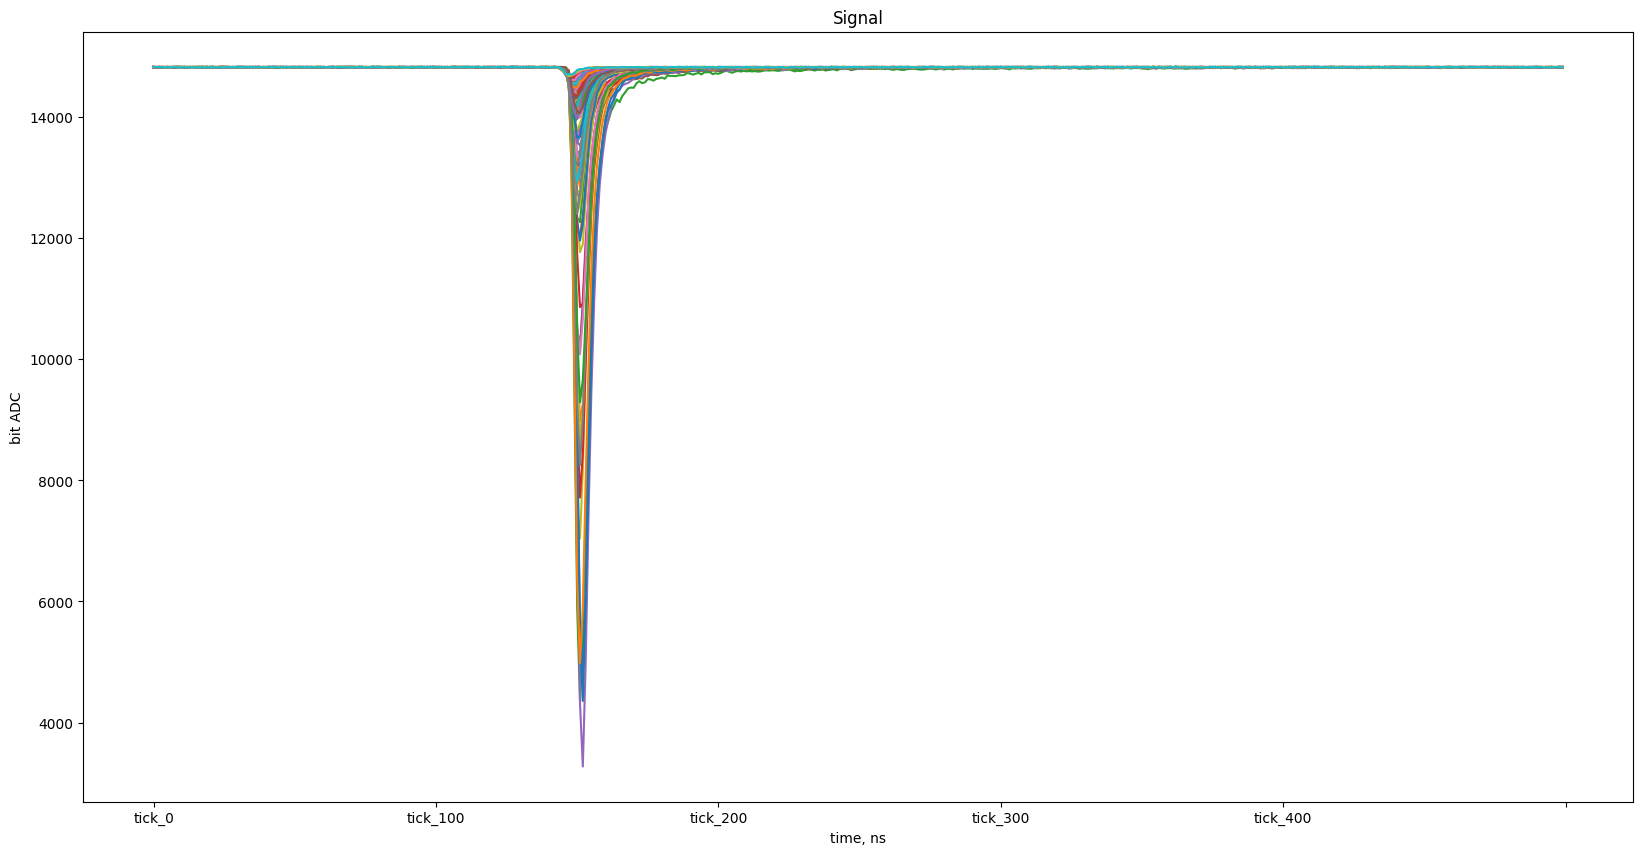

In [180]:
N=range(0,100)
ax = df_raw.T[N][:].plot(title='Signal' ,legend=None,figsize=(20,10))
ax.set_xlabel("time, ns")
ax.set_ylabel("bit ADC")

Text(0, 0.5, 'bit ADC')

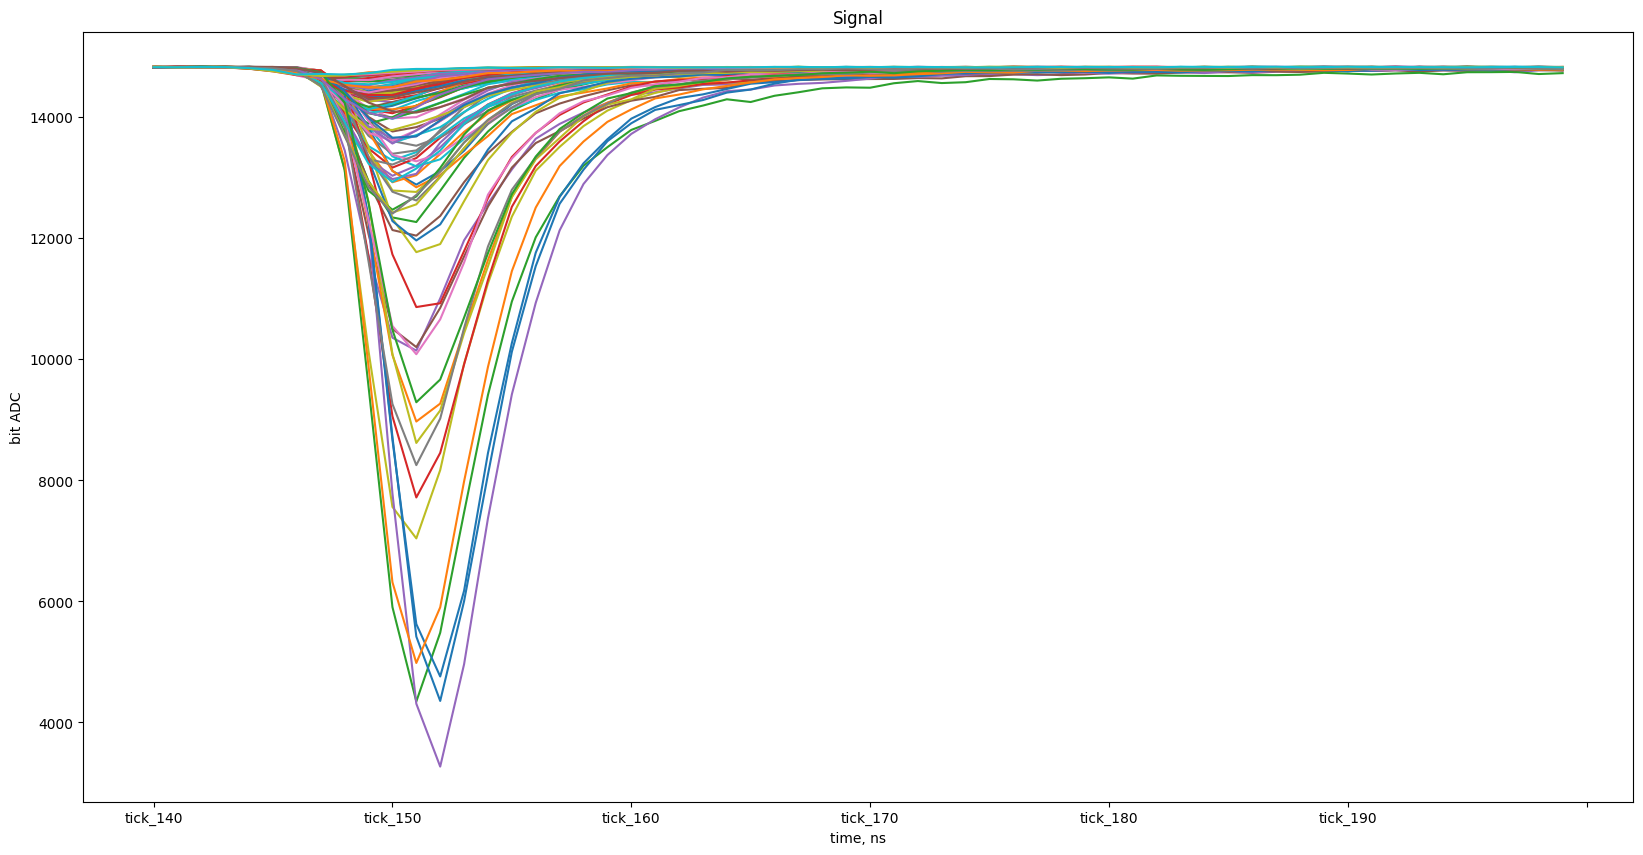

In [181]:
N=range(0,100)
ax = df_raw.T[N][140:200].plot(title='Signal' ,legend=None,figsize=(20,10))
ax.set_xlabel("time, ns")
ax.set_ylabel("bit ADC")

**Характер сигнала:** Базовый уровень ~14820 ед. Сигнал ФЭУ имеет отрицательную полярность (импульс вниз). Для корректного выделения амплитуды и площади необходима инверсия относительно baseline.

Text(0, 0.5, 'bit ADC')

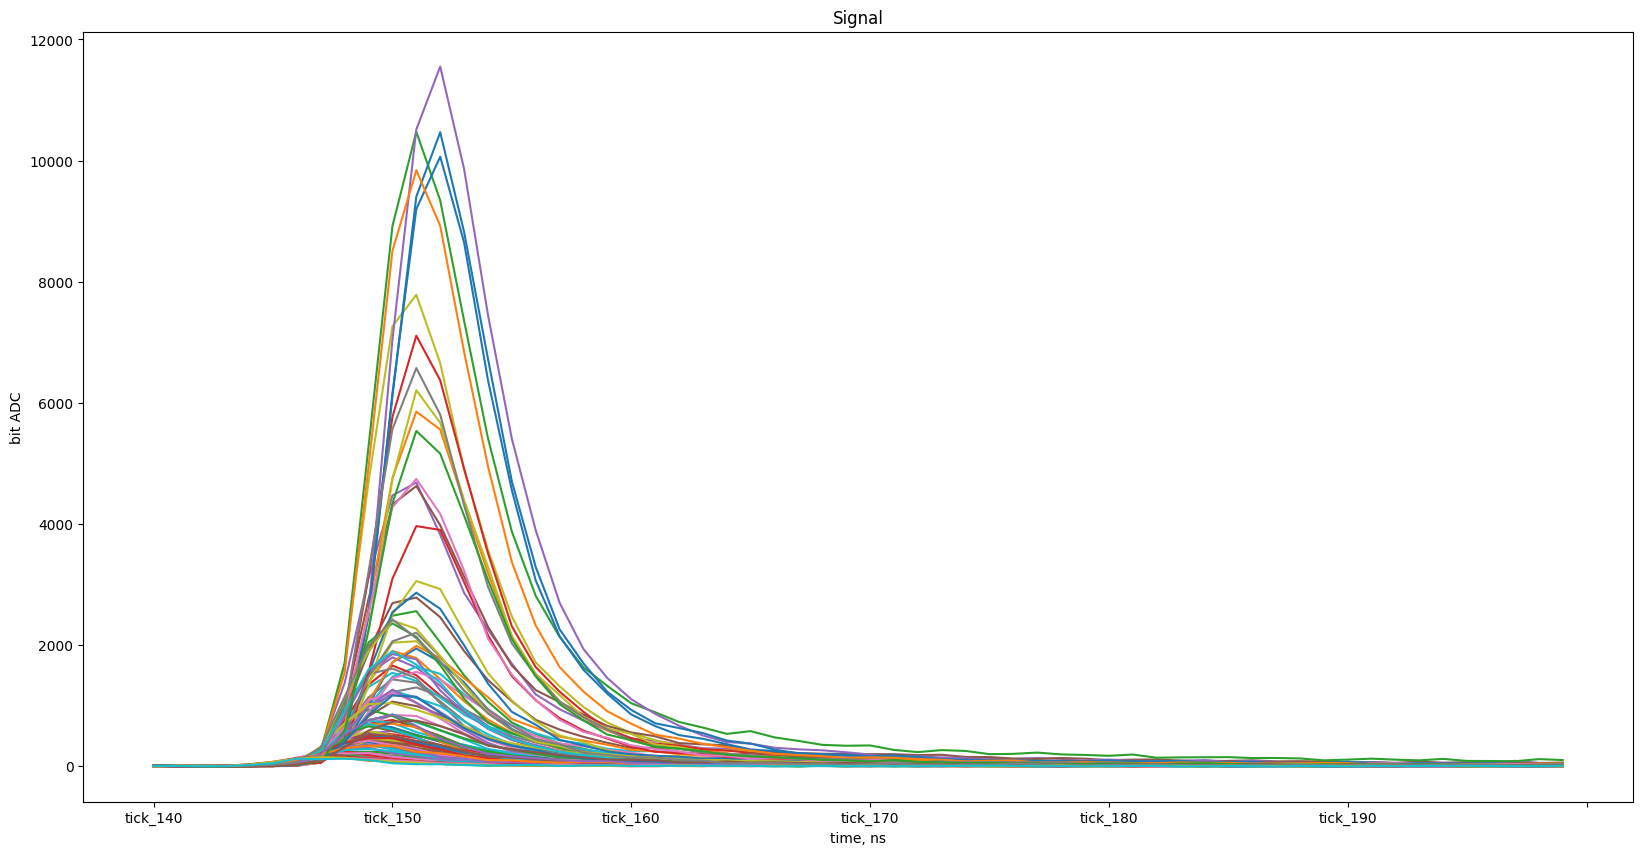

In [182]:
ax = (2**14-df_raw.T[N]-1560)[140:200].plot(title='Signal' ,legend=None,figsize=(20,10))
ax.set_xlabel("time, ns")
ax.set_ylabel("bit ADC")


### Выводы по шагу 1: 
- исходный массив имеет 23 479 строк и 505 столбцов
- дубликатов и пропусков не обнаружено 
- служебные столбцы `0`, `1`, `2`, `3`, `504` были отброшены
- из визуального анализа видно что активная фаза вспышки начинается приблизительно в один временной тик, так же как и пик сигнала

## Шаг 2: Подготовка параметров (Feature Engineering & Signal Processing)

Поскольку сигналы от гамма-квантов и нейтронов имеют практически идентичный фронт нарастания, классификация на сырых отсчетах неэффективна. Ключевое физическое различие кроется в доле медленной компоненты высвечивания.

Для разделения смеси распределений необходимо перейти к физическим признакам:
   - **Амплитуда** — максимальное значение инвертированного сигнала.
   - **Total Area (Полная площадь)** — интеграл всего полезного сигнала.
   - **Tail Area (Площадь хвоста)** — интеграл сигнала, начиная со 166-го отсчета (пик 151 + отступ 15 тактов для исключения быстрой компоненты).
   - **PSD (Pulse Shape Discrimination)** — отношение площади хвоста к полной площади. Это важнейший параметр для отделения нейтронов от гамма-квантов.

Первоначально рассчитаем `baseline`, а так же определим где в среднем находится пик 

In [183]:
baseline = df_raw.iloc[:, :50].mean(axis=1)
df_clean = df_raw.rsub(baseline, axis=0)
df_clean = df_clean.clip(lower=0)
mean_signal = df_clean.mean()
peak_tick = mean_signal.argmax()
print(f"В среднем максимум амплитуды (пик) находится на отсчете: {peak_tick}")

В среднем максимум амплитуды (пик) находится на отсчете: 151


Далее рассчитаем необходимые физические признаки

In [184]:
amplitude = df_clean.max(axis=1) # амплитуда
total_area = df_clean.sum(axis=1) # полная площадь

tail_area = df_clean.iloc[:, 166:].sum(axis=1) # площадь хвоста начиная с 166 до 500 тика

psd = tail_area / (total_area + 1e-9) # доля хвоста в общем сигнале

df_features = pd.DataFrame ({
    "Amplitude": amplitude,
    "Total_area": total_area, 
    "Tail_area": tail_area,
    "PSD": psd
})

In [185]:
display(df_features.describe())

,Amplitude,Total_area,Tail_area,PSD
count,23479.000000,23479.000000,23479.000000,23479.000000
mean,1835.104716,13517.662262,1960.195616,0.197011
std,2389.300501,16026.495292,1981.479291,0.083619
min,104.300000,1043.360000,201.800000,0.059800
25%,308.160000,2888.020000,635.720000,0.115906
50%,812.540000,6638.200000,1154.520000,0.206458
75%,2315.050000,17591.250000,2579.720000,0.257604
max,14824.840000,113281.080000,15166.180000,0.652614


Посмотрим на распределение амплитуды и PSD

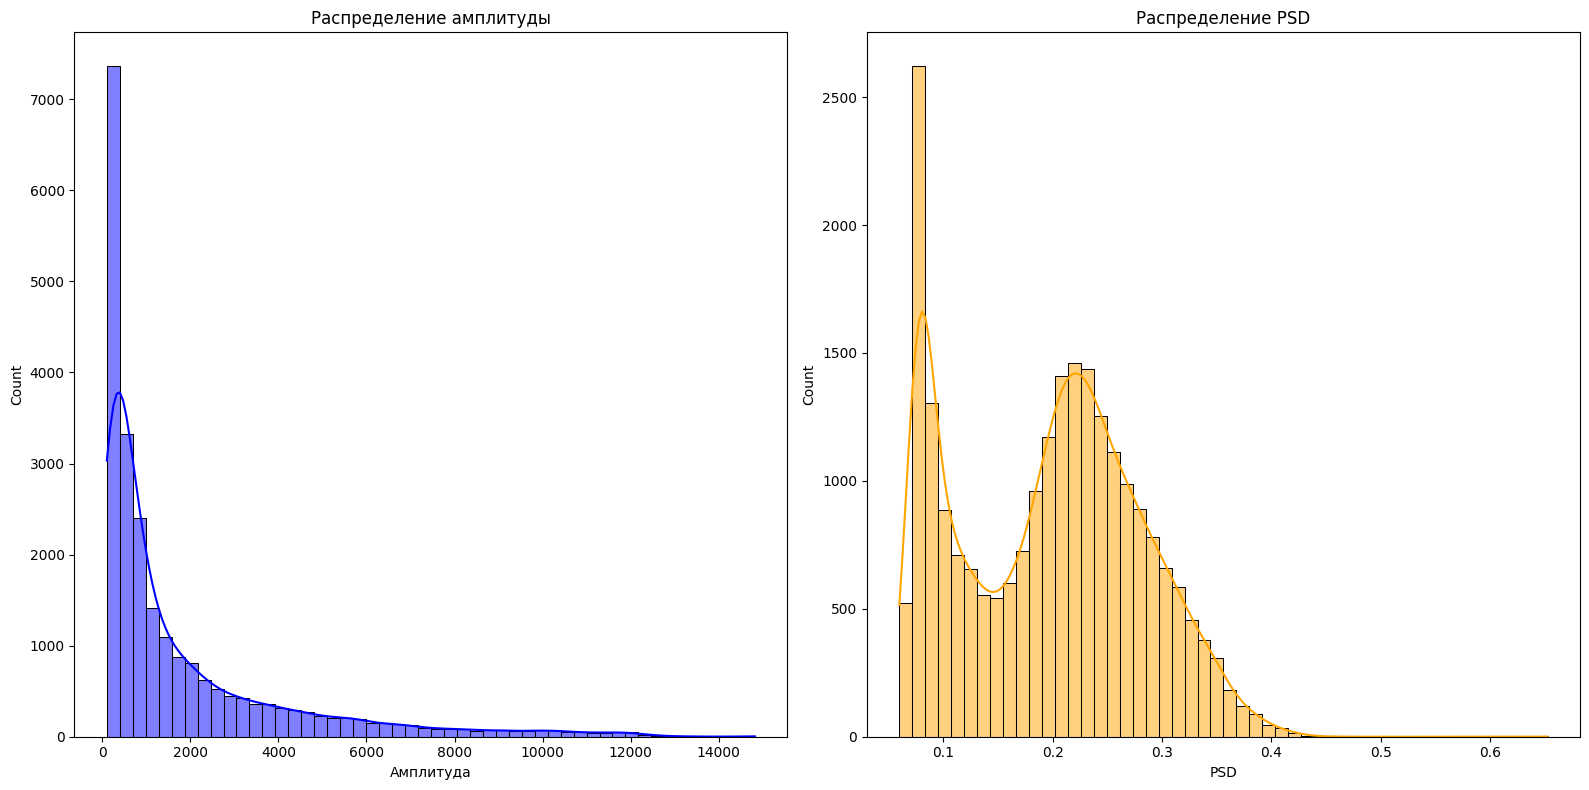

In [ ]:
plt.figure(figsize=(16, 8))

plt.subplot(1, 2, 1)
sns.histplot(df_features["Amplitude"], bins=50, kde=True, color='blue')
plt.title("Распределение амплитуды")
plt.xlabel("Амплитуда")
plt.subplot(1, 2, 2)
sns.histplot(df_features["PSD"], bins=50, kde=True, color='orange')
plt.title("Распределение PSD")
plt.xlabel("PSD")
plt.tight_layout()
plt.show()

Из графиков видно:
- Распределение параметра PSD бимодально -> есть два основных класса (гамма и нейтроны), но их распределения перекрываются `~0.15 - 0.20.`, следовательно для класстеризации одной PSD недостаточно
- на графике видно что есть аномельные значения амплитуды `> 140000` -> что свидетельствует о насыщении АЦК, для таких данных признаки теряют физический смысл

Для повышения точности и устранения перекрытия классов рассмотрим взаимосвязь амплитуды с полной площадью сигнала и PSD, для этого построим графики:

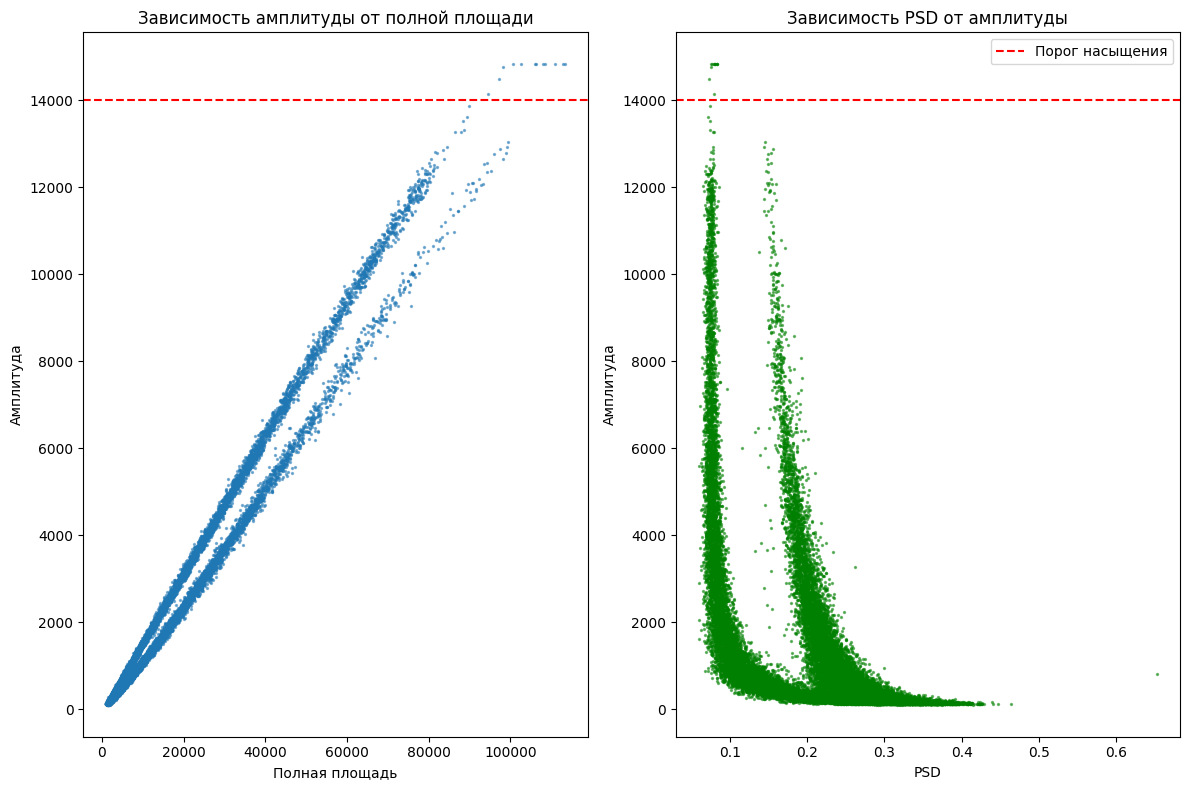

In [187]:
plt.figure(figsize=(12, 8))


plt.subplot(1, 2, 1)
plt.scatter(df_features["Total_area"], df_features["Amplitude"],s=2, alpha=0.5)
plt.title("Зависимость амплитуды от полной площади")
plt.axhline(y=14000, color='r', linestyle='--', label='Порог насыщения')
plt.xlabel("Полная площадь")
plt.ylabel("Амплитуда")


plt.subplot(1, 2, 2)
plt.scatter(df_features["PSD"], df_features["Amplitude"], alpha=0.5, s=2, color='green')
plt.title("Зависимость PSD от амплитуды")  
plt.axhline(y=14000, color='r', linestyle='--', label='Порог насыщения')
plt.ylabel("Амплитуда")
plt.xlabel("PSD")

plt.legend()
plt.tight_layout()
plt.show()

Анализ зависимостей между признаками показал наличие выраженной структуры в данных.
Амплитуда сигнала демонстрирует сильную линейную зависимость от полной площади, что указывает на высокую коррелированность признаков.
При этом наблюдается эффект насыщения, связанный с ограничениями измерительной системы.

Взаимосвязь между PSD и амплитудой носит нелинейный характер и выявляет наличие нескольких компактных групп наблюдений, что свидетельствует о существовании различных типов сигналов в выборке.

Посчитаем количество аномальных значений и их долю от общего числа сигналов

In [188]:
anomalies_count = (df_features["Amplitude"] > 14000).sum()
print(f"Количество сигналов, превышающих порог насыщения: {anomalies_count}")
print(f"Доля сигналов, превышающих порог насыщения: {anomalies_count / len(df_features) * 100:.2f}%")

Количество сигналов, превышающих порог насыщения: 12
Доля сигналов, превышающих порог насыщения: 0.05%


### Выводы по шагу 2:
- Рассчитаны 4 физических признака: Амплитуда, Полная площадь, Площадь хвоста, PSD
- Распределение PSD бимодально — наличие двух основных классов (гамма и нейтроны) с перекрытием в диапазоне 0.15–0.20
- Обнаружено 12 аномальных значений (0.05%) с амплитудой > 14000 (насыщение АЦК)
- Амплитуда имеет линейную зависимость от полной площади, указывая на высокую коррелированность признаков

## Шаг 3: Корреляционный анализ и PCA 

,Amplitude,Total_area,Tail_area,PSD
Amplitude,1.000,0.991,0.757,-0.576
Total_area,0.991,1.000,0.837,-0.525
Tail_area,0.757,0.837,1.000,-0.216
PSD,-0.576,-0.525,-0.216,1.000


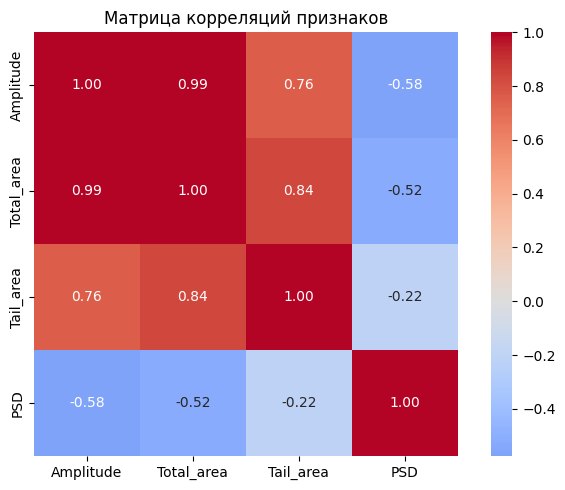

In [189]:
corr = df_features.corr(numeric_only=True)

display(corr.round(3))

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Матрица корреляций признаков')
plt.tight_layout()
plt.show()

Из матрицы корреляций видим что есть признаки с черезвычайно сильной связью (>0.9)

Выполним стандартизацию сигналов и снизим размерность

In [190]:
X_wave = df_raw.values.astype(np.float32)

baseline = X_wave[:, :50].mean(axis=1, keepdims=True)
sig = baseline - X_wave
sig = np.clip(sig, 0, None)

max_amp = sig.max(axis=1, keepdims=True)
max_amp[max_amp == 0] = 1
sig_norm = sig / max_amp

n_component = 10
pca = PCA(n_components=n_component, random_state=42)
X_pca = pca.fit_transform(sig_norm)

explained_variance = pca.explained_variance_ratio_.sum() * 100
print(f"Суммарная объясненная дисперсия {n_component} компонентами: {explained_variance:.2f}%\n")


Суммарная объясненная дисперсия 10 компонентами: 95.53%



### Выводы по шагу 3:
- 10 компонент PCA объясняют более 95% суммарной дисперсии исходных данных
- Матрица корреляций признаков показала наличие очень сильных связей (коэффициенты > 0.9)
- Нормализация сигналов по амплитуде и PCA позволили снизить размерность с 500 до 10, сохраняя информационное содержание

## Шаг 4: Кластеризация 

Обучим три модели: KMeans, Gaussian Mixture Model (GMM) и Agglomerative Clustering.

In [191]:
raw_matrix = df_raw.values.astype(np.float32)

# 1. Подготовка сигнала
baseline = raw_matrix[:, :50].mean(axis=1, keepdims=True)
signal = np.maximum(baseline - raw_matrix, 0)

amplitude = signal.max(axis=1, keepdims=True)
amplitude[amplitude < 1] = 1
normalized_signal = signal / amplitude

# 2. PCA
pca = PCA(n_components=10, random_state=42)
X_pca = pca.fit_transform(normalized_signal)

# 3. Стандартизация
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_pca)

# --- МОДЕЛИ ---
models_results = {}
print("=== Обучение моделей ===")

km = KMeans(n_clusters=3, random_state=42, n_init=10)
models_results['K-Means'] = km.fit_predict(X_scaled)

gmm = GaussianMixture(n_components=3, random_state=42, covariance_type='full')
models_results['GMM'] = gmm.fit_predict(X_scaled)

agg = AgglomerativeClustering(n_clusters=3, linkage='ward')
models_results['Agglomerative'] = agg.fit_predict(X_scaled)

# --- ОЦЕНКА ---
print("\n=== Метрики качества ===")
for name, labels in models_results.items():
    ch_score = calinski_harabasz_score(X_scaled, labels)
    sil_score = silhouette_score(X_scaled, labels, sample_size=10000)
    print(f"[{name}] CH={ch_score:.2f} | Sil={sil_score:.4f}")


=== Обучение моделей ===

=== Метрики качества ===
[K-Means] CH=2259.49 | Sil=0.1213
[GMM] CH=1826.13 | Sil=0.0492
[Agglomerative] CH=1857.74 | Sil=0.0813


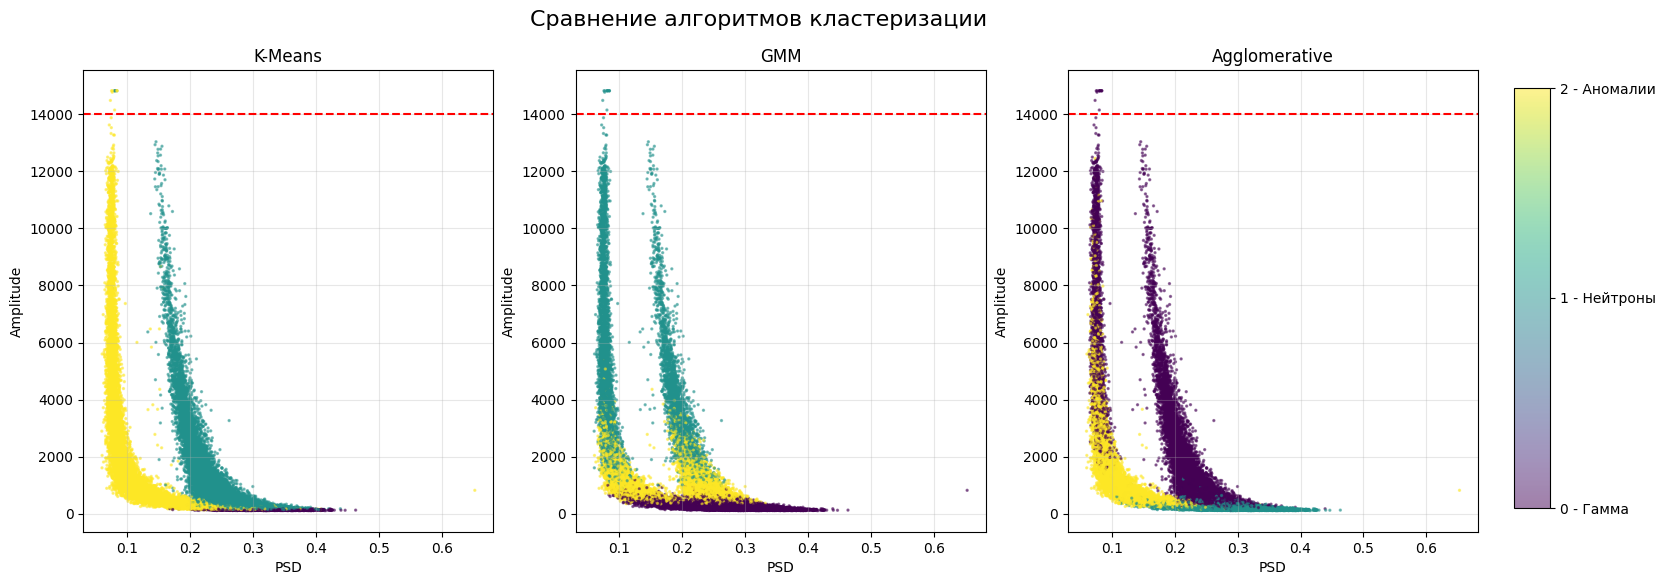

In [192]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Сравнение алгоритмов кластеризации', fontsize=16)

for i, (name, labels) in enumerate(models_results.items()):
    scatter = axes[i].scatter(
        df_features['PSD'],
        df_features['Amplitude'],
        c=labels,
        cmap='viridis',
        s=2,
        alpha=0.5
    )

    axes[i].set_title(name)
    axes[i].set_xlabel('PSD')
    axes[i].set_ylabel('Amplitude')
    axes[i].axhline(14000, color='red', linestyle='--')
    axes[i].grid(alpha=0.3)

cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
cbar = fig.colorbar(scatter, cax=cbar_ax, ticks=[0, 1, 2])
cbar.set_ticklabels(['0 - Гамма', '1 - Нейтроны', '2 - Аномалии'])

plt.subplots_adjust(right=0.9)
plt.show()

Метод K‑means показал наилучшее разделение данных. Однако в процессе кластеризации метки кластеров были присвоены произвольно (номера не соответствуют исходным классам).Используем маппинг меток для сопоставления с истинными классами.

### Выводы по шагу 4:
- Обучены три модели кластеризации: K-Means, GMM, Agglomerative Clustering
- K-Means показал наилучшие метрики качества (наивысший Calinski-Harabasz score и Silhouette score)
- Далее будет применён маппинг кластеров K-Means для соответствия физическим классам: гамма (0), нейтроны (1), аномалии (2)

## Шаг 5: Маппинг и запись результатов

In [193]:
# Явная перенумерация кластеров KMeans:
# 2 -> 1, 1 -> 0, 0 -> 2
mapping = {2: 1, 1: 0, 0: 2}

kmeans_labels = models_results['K-Means']
final_labels = np.array([mapping[label] for label in kmeans_labels], dtype=int)

submission = pd.DataFrame({
    'index': np.arange(len(final_labels)),
    'cluster': final_labels
})

submission.to_csv('submission.csv', index=False)

print('Использован маппинг:', mapping)
print('Распределение новых меток:')
print(submission['cluster'].value_counts().sort_index())
print(f'\nФайл сохранен: submission.csv, строк: {len(submission)}')
submission.head(10)

Использован маппинг: {2: 1, 1: 0, 0: 2}
Распределение новых меток:
cluster
0    10839
1    10919
2     1721
Name: count, dtype: int64

Файл сохранен: submission.csv, строк: 23479


,index,cluster
0,0,0
1,1,1
2,2,1
3,3,0
4,4,1
5,5,0
6,6,0
7,7,0
8,8,1
9,9,0


---

## Результат проекта

**Выходные данные:** файл `submission.csv` с предсказанными метками кластеров.

**Формат:**
- Колонка `index` — порядковый номер сигнала (0...23478)
- Колонка `cluster` — предсказанный класс (0 = гамма, 1 = нейтроны, 2 = аномалии)

**Использованный метод:** K-Means кластеризация на 10 главных компонентах амплитудно-нормализованных сигналов

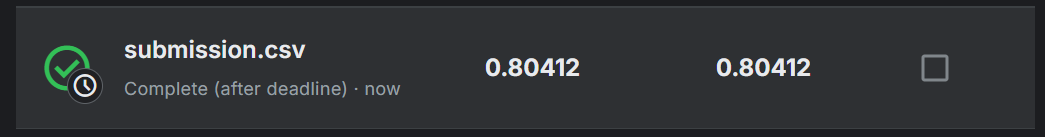

---

## Общий вывод

Задача успешно решена: сигналы со сцинтилляционного детектора разделены на 3 класса (гамма-кванты, нейтроны, аномалии). 

**Ключевые этапы:**
1. Извлечены физические признаки (амплитуда, площадь, PSD), выявлена бимодальность распределений
2. Применена стандартизация и PCA-снижение размерности с 500 до 10 признаков
3. K-Means кластеризация показала лучший результат среди трёх протестированных моделей
4. Результат экспортирован в submission.csv
